In [27]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import flexible_figure

In [28]:
experiment_dir = Path("/dcs/large/u1508153/misdro/kl_newsvendor_1d")
assert experiment_dir.exists()
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])

num_total_samples = []
for _, row in all_results_df.iterrows():
    if row["algorithm"] == "kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"] ** 2)
    elif row["algorithm"] == "kl_dro_bas":
        num_total_samples.append(row["num_likelihood_samples"])
all_results_df["num_total_samples"] = num_total_samples

In [52]:
# NOTE filter by DGP
results_df = all_results_df.loc[all_results_df["dgp"] == "exponential"]

# NOTE filter out when log_partition_constant G is less than epsilon
results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]

results_df

mean_cost      var_cost  \
uuid                                 replication                             
46dbe6bc-061e-4433-9369-bca4b16d01fc 0            111.752632   1460.272120   
                                     1            102.566327  36219.686343   
                                     2             60.027412   4061.608930   
                                     3             96.853310  15482.350658   
                                     4             95.654650  22400.342120   
...                                                      ...           ...   
380158c7-6cfa-4e27-994d-5e72be6919a1 195          136.583607   2240.398503   
                                     196          132.593755   2312.026460   
                                     197          156.791318   4824.688096   
                                     198          125.132718   6507.556317   
                                     199          179.197085  14721.588384   

                                                   solution  dgp_time  \
uuid                                 replication                        
46dbe6bc-061e-4433-9369-bca4b16d01fc 0            53.893417  0.000174   
                                     1            23.993086  0.000219   
                                     2            24.992126  0.000193   
                                     3            21.271993  0.000196   
                                     4            22.572682  0.000199   
...                                                     ...       ...   
380158c7-6cfa-4e27-994d-5e72be6919a1 195          62.378422  0.000363   
                                     196          58.955898  0.000227   
                                     197          73.704690  0.000309   
                                     198          54.698178  0.000288   
                                     199          73.555421  0.000290   

                                                  likelihood_time  \
uuid                                 replication                    
46dbe6bc-061e-4433-9369-bca4b16d01fc 0                   0.000069   
                                     1                   0.000074   
                                     2                   0.000069   
                                     3                   0.000070   
                                     4                   0.000073   
...                                                           ...   
380158c7-6cfa-4e27-994d-5e72be6919a1 195                 0.004012   
                                     196                 0.003101   
                                     197                 0.003967   
                                     198                 0.003237   
                                     199                 0.003401   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
46dbe6bc-061e-4433-9369-bca4b16d01fc 0                  0.000029    0.154347   
                                     1                  0.000031    0.026389   
                                     2                  0.000030    0.029907   
                                     3                  0.000028    0.031663   
                                     4                  0.000030    0.030879   
...                                                          ...         ...   
380158c7-6cfa-4e27-994d-5e72be6919a1 195                0.000169    1.043676   
                                     196                0.000100    0.977964   
                                     197                0.000132    0.886700   
                                     198                0.000139    0.926574   
                                     199                0.000186    0.858287   

                                                  setup_time  \
uuid                                 replication               
46dbe6bc-061e-4433-

In [53]:
gb = results_df.groupby(by=["algorithm", "dgp", "epsilon", "inference", "posterior", "num_posterior_samples", "num_likelihood_samples"])
agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "setup_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"],
})
agg_df

mean_cost  \
                                                                                                       mean   
algorithm  dgp         epsilon inference posterior num_posterior_samples num_likelihood_samples               
kl_bdro    exponential 0.001   bayes     gamma     5                     5                        83.819836   
                                                   10                    10                       81.835808   
                                                   30                    30                       80.113431   
                                                   50                    50                       79.959720   
                       0.002   bayes     gamma     5                     5                        83.794260   
...                                                                                                     ...   
kl_dro_bas exponential 2.500   bayes     gamma     1                     2500                    225.689799   
                       3.000   bayes     gamma     1                     25                      120.622986   
                                                                         100                     159.735512   
                                                                         900                     211.330703   
                                                                         2500                    227.052185   

                                                                                                              \
                                                                                                         var   
algorithm  dgp         epsilon inference posterior num_posterior_samples num_likelihood_samples                
kl_bdro    exponential 0.001   bayes     gamma     5                     5                        269.255197   
                                                   10                    10                       221.533912   
                                                   30                    30                       216.122188   
                                                   50                    50                       213.998026   
                       0.002   bayes     gamma     5                     5                        268.617206   
...                                                                                                      ...   
kl_dro_bas exponential 2.500   bayes     gamma     1                     2500                     798.507958   
                       3.000   bayes     gamma     1                     25                      2115.176868   
                                                                         100                     2462.898769   
                                                                         900                     1358.329128   
                                                                         2500                     734.175282   

                                                                                                    var_cost  \
                                                                                                        mean   
algorithm  dgp         epsilon inference posterior num_posterior_samples num_likelihood_samples                
kl_bdro    exponential 0.001   bayes     gamma     5                     5                       9948.300613   
                                                   10                    10                      9961.603850   
                                                   30                    30                      9783.860147   
                                                   50                    50                      9800.816304   
                       0.002   bayes     gamma     5                     5                       9949.671790   
...                                                                           

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


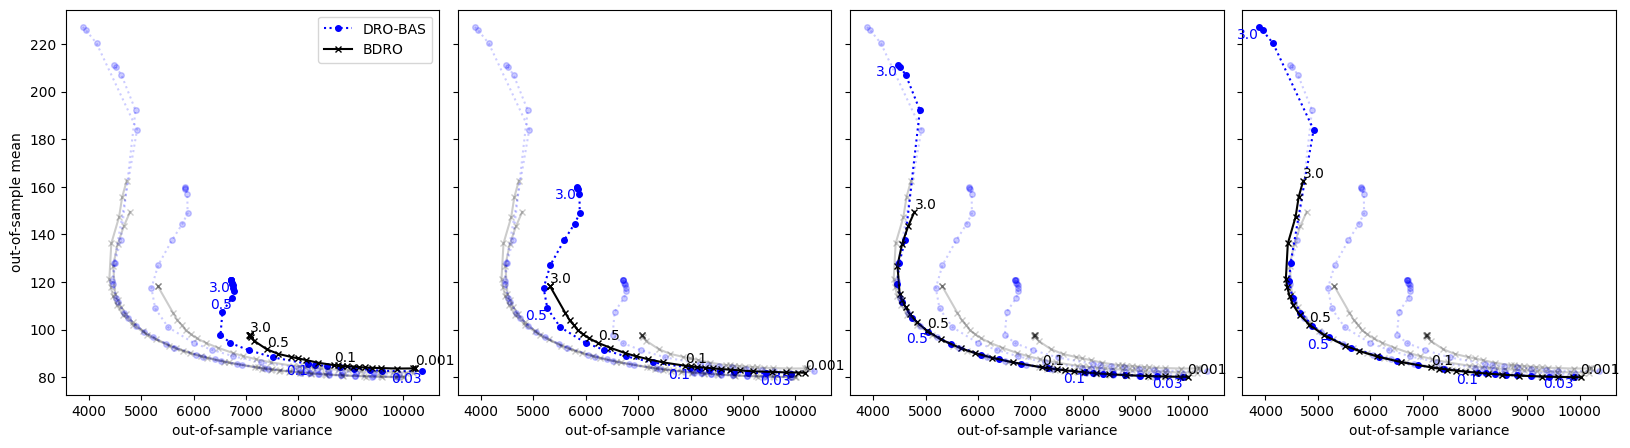

In [54]:
from mis_dro.plot import mean_variance_plot, algorithm_style, AlgorithmColor

from enum import StrEnum

def mean_variance_plot(
    axis,
    df: pd.DataFrame,
    is_labelled: bool = True,
    **kwargs,
) -> None:
    posterior_var = df["var_cost"]["mean"] + df["mean_cost"]["var"]

    # plot mean-variance trade-off
    epsilon_list = list(df.index.get_level_values("epsilon"))
    axis.plot(posterior_var, df["mean_cost"]["mean"], **kwargs, markersize=4)
    # axis.scatter(posterior_var, df["mean_cost"]["mean"], s=100*np.sqrt(np.array(epsilon_list)), **kwargs)
    if is_labelled:
        
        for i, epsilon in enumerate(epsilon_list):
            # if i % 4 == 0:

            if i == 0 or i == len(epsilon_list) - 1 or epsilon in (0.1, 0.5):
                # if line is blue then put text on bottom left
                if kwargs["color"] == AlgorithmColor.kl_dro_bas:
                    ha = "right"
                    va = "top"
                    # offset = -1 if i==0 or i == len(epsilon_list) else -5
                    offset = -1

                # else if line is black then put text on top right
                elif kwargs["color"] == AlgorithmColor.kl_bdro:
                    ha = "left"
                    va = "bottom"
                    # offset = 1 if i==0 or i == len(epsilon_list) else 5
                    offset = 1

                axis.text(
                    posterior_var[:, :, epsilon, :].iloc[0] + offset,
                    df["mean_cost"]["mean"][:, :, epsilon, :].iloc[0],
                    epsilon,
                    ha=ha,
                    va=va,
                    color=kwargs["color"],
                )

class NiceNameDGP(StrEnum):
    normal = "Normal DGP"
    truncated_normal = "Truncated Normal DGP"

# NOTE if you want to visual only one DGP, then uncomment the below lines
# only_dgp = "normal"
# agg_df = agg_df.loc[:, only_dgp, :, :]

compare_col="algorithm"
gb_col="dgp"
likelihood_sr = agg_df.index.get_level_values("num_likelihood_samples")
posterior_sr = agg_df.index.get_level_values("num_posterior_samples")

TOTAL_SAMPLES = [25, 100, 900, 2500]
nrows = len(agg_df.index.get_level_values("dgp").unique())
ncols = len(TOTAL_SAMPLES)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)

for j, total_samples in enumerate(TOTAL_SAMPLES):
    df = agg_df.loc[(
        (likelihood_sr == int(np.sqrt(total_samples))) & (posterior_sr == int(np.sqrt(total_samples)))
        | (likelihood_sr == total_samples) & (posterior_sr == 1)
    )]
    df = df.reset_index(level=["num_posterior_samples", "num_likelihood_samples"], drop=True)
    gb = df.groupby(gb_col)

    for k in range(len(TOTAL_SAMPLES)):
        if j == k:
            alpha = 1.0
            is_labelled = True
        else:
            alpha = 0.2
            is_labelled = False
        for i, (group, group_df) in enumerate(gb):
            index_set = set(
                zip(
                    group_df.index.get_level_values("algorithm"),
                    group_df.index.get_level_values("dgp"),
                    group_df.index.get_level_values("inference"),
                    group_df.index.get_level_values("posterior"),
                )
            )
            if k == 0:
                axes[k].set_ylabel("out-of-sample mean")
                axes[k].legend()
            axes[k].set_xlabel("out-of-sample variance")

            # axes[i, k].set_title(f"{NiceNameDGP[group].value} with {n_total_samples_sqrt**2} samples")
            # add a new plot on the same axis for each parameter setting
            for algorithm, dgp, inference, posterior in index_set:
                style = algorithm_style(algorithm)
                line_label = ""
                if k == 0 and j == k:
                    line_label = style.pop("label")
                else:
                    style.pop("label")
                mean_variance_plot(axes[k], group_df.loc[algorithm, dgp, :np.inf, inference, posterior], **style, alpha=alpha, is_labelled=is_labelled, label=line_label)

fig.show()

## Solve time

In [71]:
results_df["is_warm_start"] = results_df.index.get_level_values("replication") == 0

# solve_time_df = results_df.groupby(["algorithm", "dgp", "num_total_samples", "is_warm_start"]).agg({"solve_time": ["mean", "std"]}).unstack(level="dgp").unstack(level="algorithm")
solve_time_df = results_df.groupby(["algorithm", "num_total_samples", "is_warm_start"]).agg({"solve_time": ["mean", "std"]}).unstack(level="algorithm").swaplevel(1,2, axis="columns")

solve_time_df


solve_time                                
algorithm                           kl_bdro kl_dro_bas   kl_bdro kl_dro_bas
                                       mean       mean       std        std
num_total_samples is_warm_start                                            
25                False            0.010567   0.012621  0.002616   0.002853
                  True             0.069267   0.031753  0.021745   0.026755
100               False            0.029179   0.026439  0.004631   0.006688
                  True             0.157294   0.036695  0.029869   0.001650
900               False            0.283834   0.476078  0.034343   0.169956
                  True             5.680139   0.298948  0.057329   0.026960
2500              False            1.186842   2.181873  0.210173   0.589386
                  True           100.990736   1.125273  0.457965   0.101601

In [36]:
print(solve_time_df.to_latex())

\begin{tabular}{lrr}
\toprule
 & \multicolumn{2}{r}{solve_time} \\
 & \multicolumn{2}{r}{mean} \\
dgp & \multicolumn{2}{r}{exponential} \\
algorithm & kl_bdro & kl_dro_bas \\
num_total_samples &  &  \\
\midrule
25 & 0.010861 & 0.012717 \\
100 & 0.029820 & 0.026490 \\
900 & 0.310816 & 0.475192 \\
2500 & 1.685862 & 2.176590 \\
\bottomrule
\end{tabular}



# Constant $G(\tau_n)$ and expected KL

In [37]:

from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.constants import NUM_REPLICATIONS, NUM_OBSERVATIONS, NUM_TEST_OBSERVATIONS
from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import default_prior_params, get_posterior_params, get_log_partition_constant, derive_analytical_posterior_params
from mis_dro.newsvendor import BACKORDER_COST, HOLDING_COST, newsvendor_cost_cvxpy

def normal_newsvendor_optimal_solution(dgp_mean, dgp_std):
    return sp.stats.norm.ppf(BACKORDER_COST / (BACKORDER_COST + HOLDING_COST), dgp_mean, dgp_std)


def expected_kl_normal_gamma(dgp_mean, dgp_std, theta_params):
    mu_posterior, _, alpha_posterior, beta_posterior = theta_params
    dgp_precision = 1 / (dgp_std ** 2)
    term1 = np.log(np.sqrt(dgp_precision * (beta_posterior / alpha_posterior)))
    term2 = (dgp_std ** 2 + (dgp_mean - mu_posterior)**2) / (2 * (beta_posterior / alpha_posterior))
    return term1 + term2 - 0.5 + get_log_partition_constant("normal_gamma", theta_posterior)

dgp = "normal"
posterior = "normal_gamma"
num_observations = NUM_OBSERVATIONS
G_constant = []             # calculate the constant G
posterior_expected_kl = []  # assuming normal DGP, what is expectation under the posterior of the KL between the DGP and the likelihood?
prior_expected_kl = []      # assuming normal DGP, what is expectation under the prior of the KL between the DGP and the likelihood?
opt_sol = normal_newsvendor_optimal_solution(25, DGP_STD_TRUNCATED_NORMAL)  # optimal solution

opt_costs = np.zeros((NUM_REPLICATIONS, NUM_TEST_OBSERVATIONS))
for j in range(NUM_REPLICATIONS):
    generator = np.random.default_rng(seed=j)
    data = sample_dgp(
        dgp, num_observations, generator=generator
    )
    data_eval = sample_dgp(
        dgp, NUM_TEST_OBSERVATIONS, contamination=0.0, generator=generator
    )
    theta_prior = default_prior_params(posterior)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    G_constant.append(get_log_partition_constant(posterior, theta_posterior))
    posterior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_posterior))
    prior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_prior))
    opt_costs[j] = newsvendor_cost_cvxpy(opt_sol, data_eval).value
np.max(G_constant), np.var(G_constant)

(0.04688086567534833, 0.0)

In [38]:
np.mean(posterior_expected_kl), np.var(posterior_expected_kl)

(0.08892539135699731, 0.0022999465683889984)

In [39]:
np.mean(prior_expected_kl), np.var(prior_expected_kl)

(359.7442957726813, 0.0)

# Mean squared error between our solution and the solution under the DGP


In [40]:
mean_cost = np.mean(opt_costs, axis=1)
var_cost = np.var(opt_costs, axis=1)
mean_of_means = np.mean(mean_cost)
mean_of_variances = np.mean(var_cost)
var_of_means = np.var(mean_cost)
opt_sol, mean_of_variances, var_of_means

(31.045853465832373, 809.5869569415518, 16.31412063772674)